In [ ]:
"""

CCPS844 Project - Derek Eliopoulos

Table of Contents:

1 - Select a dataset or datasets of your choice. Here are few links that can be helpful for you to select a 
dataset.
2 - Once you have selected a dataset or datasets of your choice. After reading the datasets, check the type 
of different attributes/columns/features to ensure that you have appropriate types 
(categorical/numerical) for your columns.
3 - Use visualization to understand your data
4 - For exploratory analysis, apply clustering algorithms (K means/ Hierarchical clustering) to improve your 
understanding
5 - Apply the concepts learned in Module 9 to select the features
6 – Try to reduce the dimensions of the data if possible (Apply a dimensionality reduction algorithm). For 
step 7 use both the original data and the data that you get after applying the Step 6.
7 - Divide your data in Train and Test or choose cross validation to evaluate the selected model
- Apply all learned classification algorithms to choose which one performs best
- Apply all learned regression algorithms to choose which one performs best
Please note that you need to get your data in appropriate format before applying a classification or 
regression algorithm. One of the differences is: class variable for a regression model is numeric whereas 
it is categorical for classification.
    

In [ ]:
#1 - Select a dataset or datasets of your choice. Here are few links that can be helpful for you to select a 
#dataset.

In [1]:
import pandas as pd

# Load the CSV file
df = pd.read_csv('Electric_Vehicle_Population_Data.csv')


In [ ]:
#I settled on this data set not only because it was the most popular one available, but also because it was something I was interested in seeing the data for
#from https://catalog.data.gov/dataset/electric-vehicle-population-data

In [ ]:
#2 - Once you have selected a dataset or datasets of your choice. After reading the datasets, check the type 
#of different attributes/columns/features to ensure that you have appropriate types 
#(categorical/numerical) for your columns.

In [2]:
print(df.info())
print(df.describe())
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200048 entries, 0 to 200047
Data columns (total 17 columns):
 #   Column                                             Non-Null Count   Dtype  
---  ------                                             --------------   -----  
 0   VIN (1-10)                                         200048 non-null  object 
 1   County                                             200044 non-null  object 
 2   City                                               200044 non-null  object 
 3   State                                              200048 non-null  object 
 4   Postal Code                                        200044 non-null  float64
 5   Model Year                                         200048 non-null  int64  
 6   Make                                               200048 non-null  object 
 7   Model                                              200048 non-null  object 
 8   Electric Vehicle Type                              200048 non-null  object

In [30]:
#just printing everything out to get a basic sense of it and the different values it had
#also just to make sure I actually downloaded it right
#also to see that it has the appropriate types of data

In [3]:
# Copy the DataFrame to avoid any unintended modifications to the original data
df_cleaned = df.copy()

# Fill missing values with appropriate methods (mean, median, mode, etc.)
df_cleaned['County'] = df_cleaned['County'].fillna(df_cleaned['County'].mode()[0])
df_cleaned['City'] = df_cleaned['City'].fillna(df_cleaned['City'].mode()[0])
df_cleaned['Postal Code'] = df_cleaned['Postal Code'].fillna(df_cleaned['Postal Code'].median())
df_cleaned['Legislative District'] = df_cleaned['Legislative District'].fillna(df_cleaned['Legislative District'].median())
df_cleaned['Vehicle Location'] = df_cleaned['Vehicle Location'].fillna('Unknown')
df_cleaned['Electric Utility'] = df_cleaned['Electric Utility'].fillna('Unknown')
df_cleaned['2020 Census Tract'] = df_cleaned['2020 Census Tract'].fillna(df_cleaned['2020 Census Tract'].median())

# Drop any remaining rows with missing values if necessary
df_cleaned.dropna(inplace=True)

# Verify if there are still missing values
print(df_cleaned.isnull().sum())


VIN (1-10)                                           0
County                                               0
City                                                 0
State                                                0
Postal Code                                          0
Model Year                                           0
Make                                                 0
Model                                                0
Electric Vehicle Type                                0
Clean Alternative Fuel Vehicle (CAFV) Eligibility    0
Electric Range                                       0
Base MSRP                                            0
Legislative District                                 0
DOL Vehicle ID                                       0
Vehicle Location                                     0
Electric Utility                                     0
2020 Census Tract                                    0
dtype: int64


In [ ]:
#this was to ensure the data was clean and had no missing values, using the column names learned from the last step

In [ ]:
#3 - Use visualization to understand your data

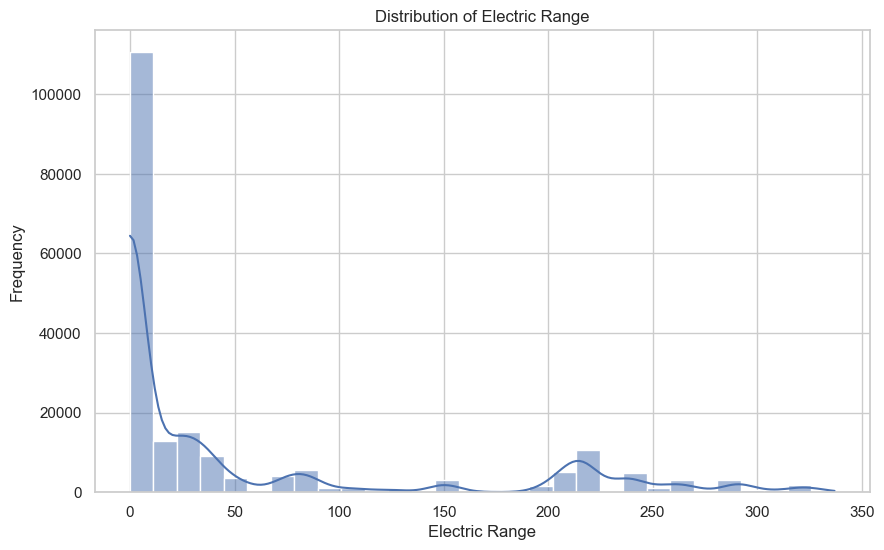

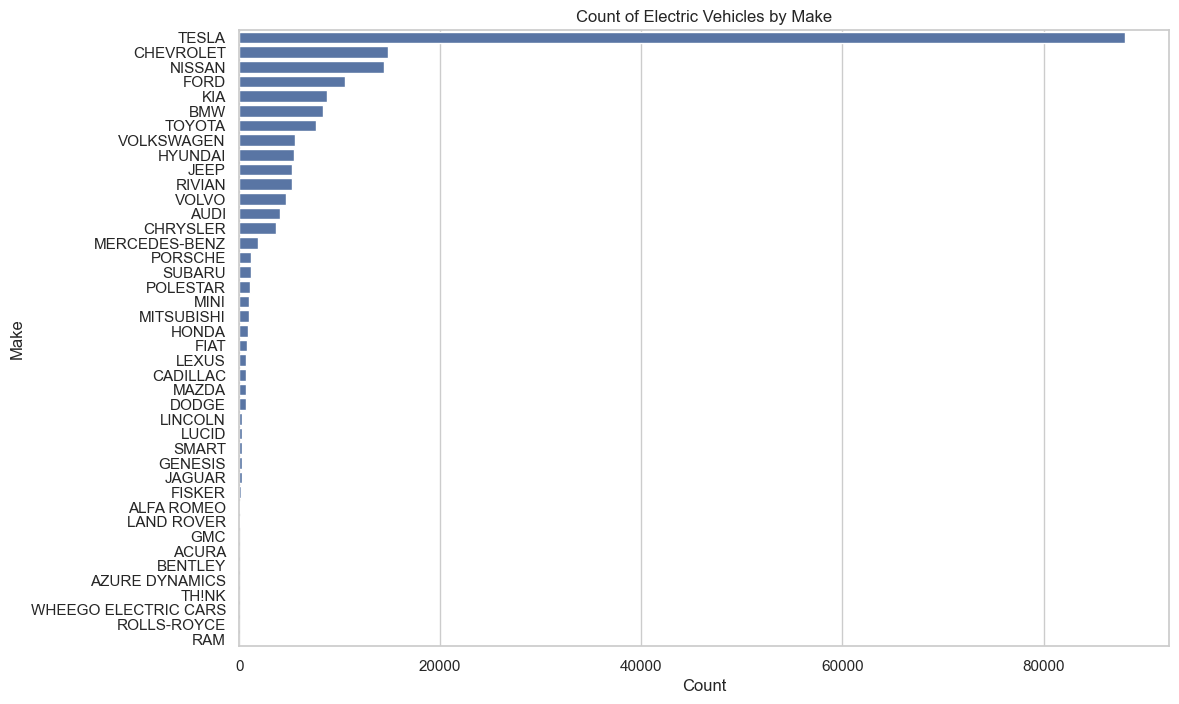

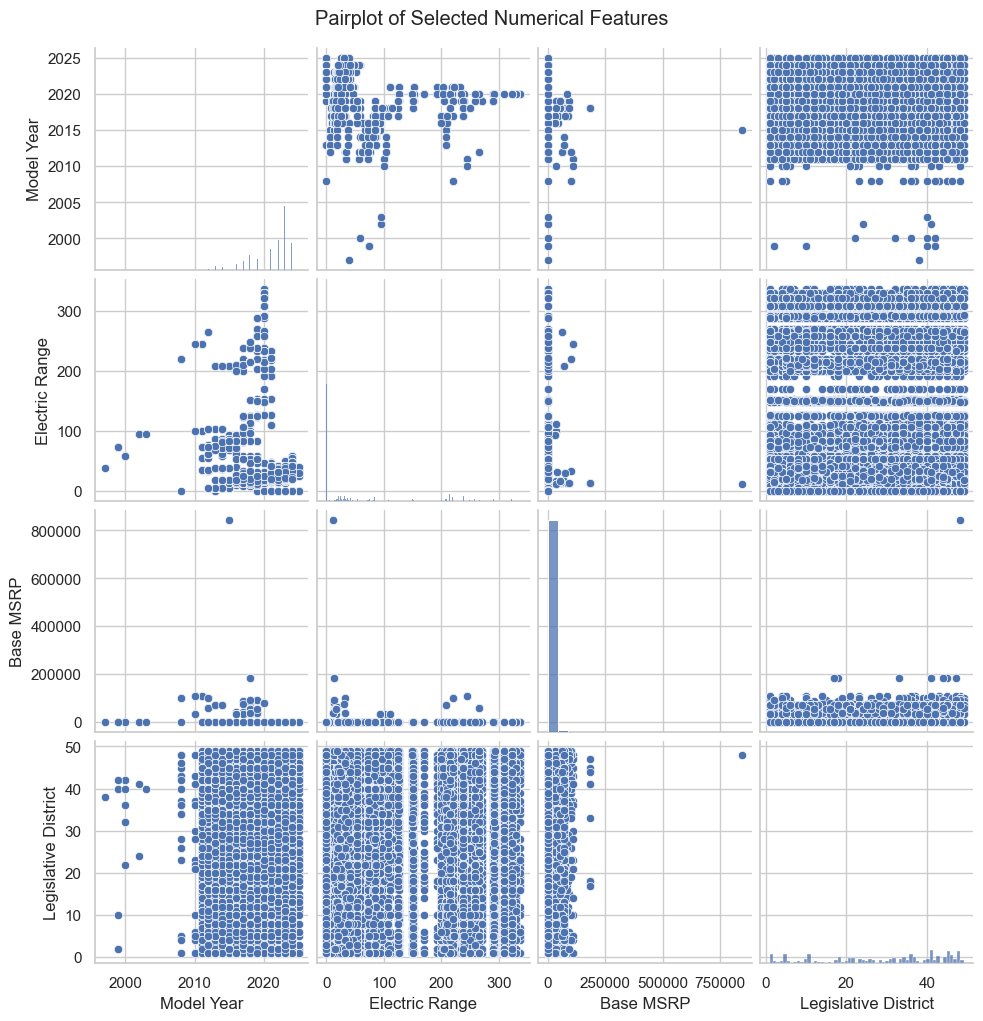

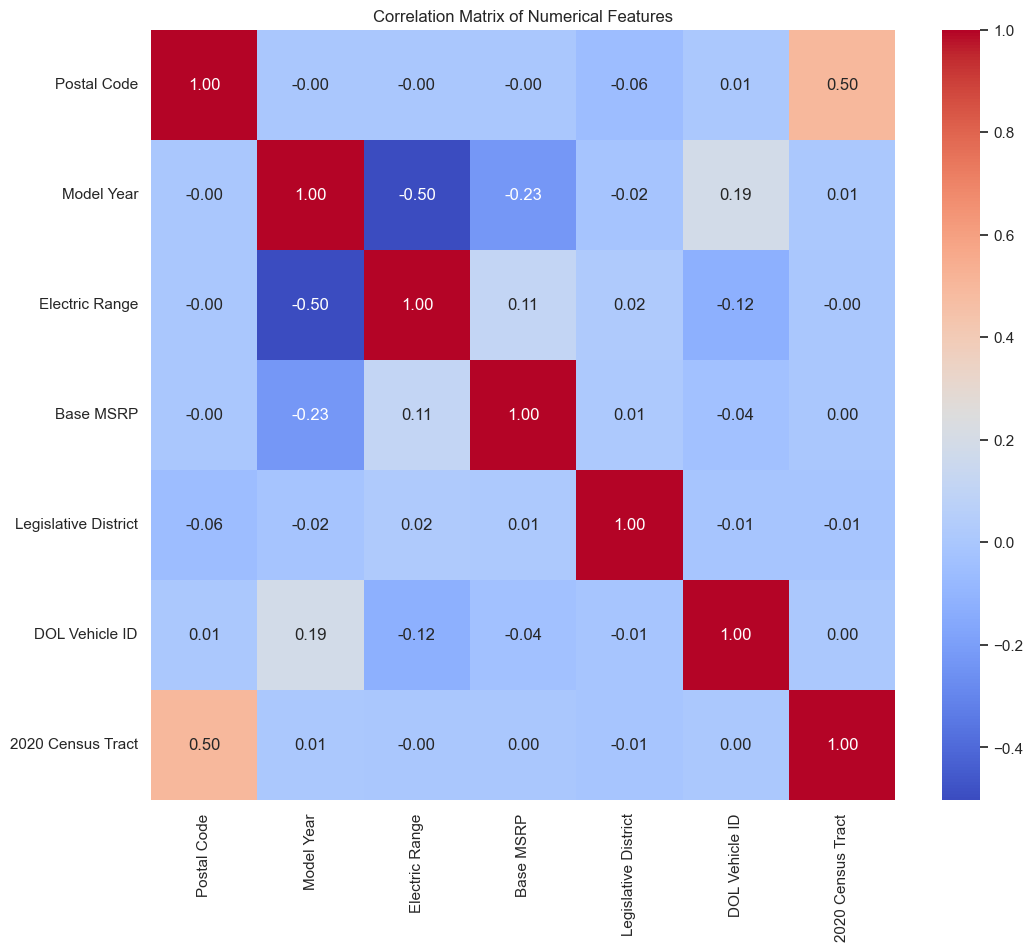

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns


sns.set(style="whitegrid")

# Histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Electric Range'], bins=30, kde=True)
plt.title('Distribution of Electric Range')
plt.xlabel('Electric Range')
plt.ylabel('Frequency')
plt.show()

# Count plot
plt.figure(figsize=(12, 8))
sns.countplot(y='Make', data=df_cleaned, order=df_cleaned['Make'].value_counts().index)
plt.title('Count of Electric Vehicles by Make')
plt.xlabel('Count')
plt.ylabel('Make')
plt.show()

# Pairplot
sns.pairplot(df_cleaned[['Model Year', 'Electric Range', 'Base MSRP', 'Legislative District']])
plt.suptitle('Pairplot of Selected Numerical Features', y=1.02)
plt.show()

# Select only the numeric columns from the DataFrame
# Had to add this after previous error message made it clear it was necessary
numeric_columns = df_cleaned.select_dtypes(include=['float64', 'int64']).columns

# Calculate the correlation matrix only for the numeric columns
corr_matrix = df_cleaned[numeric_columns].corr()

# Plot the heatmap of the correlation matrix
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()



In [ ]:
#In this step, I am conducting exploratory data analysis (EDA) using various visualization techniques to better understand the distribution and relationships of key features in the dataset. Visualization is a critical part of EDA as it provides insights that are not immediately obvious from raw data alone. Specifically, I am focusing on understanding the distribution of the Electric Range feature, the distribution of electric vehicle makes, and the relationships between selected numerical features. Additionally, I am calculating and visualizing the correlation matrix to identify potential multicollinearity between the numerical features.
#The histogram provides a visual representation of the distribution of the Electric Range across the dataset. Understanding this distribution helps in identifying any skewness, outliers, or unusual patterns that may influence the analysis. The addition of a Kernel Density Estimate (KDE) helps in visualizing the underlying distribution.
#The count plot illustrates the frequency of different electric vehicle makes in the dataset. This visualization helps in understanding the popularity or prevalence of specific vehicle makes, which is important when the target variable is Make. It allows us to assess the class distribution, which can impact model performance, especially in classification tasks.
#The pairplot shows the pairwise relationships between the Model Year, Electric Range, Base MSRP, and Legislative District features. This visualization is helpful for spotting trends, correlations, and potential interactions between features that may be useful in the modeling phase. It also provides an early indication of which features might be more influential.
#The correlation matrix is calculated only for the numerical columns. The heatmap visualization of this matrix allows us to easily identify strong correlations between features, which might suggest redundancy or multicollinearity. Understanding these correlations is crucial for feature selection and for making decisions about which features to include in the modeling process.

In [ ]:
#4 - For exploratory analysis, apply clustering algorithms (K means/ Hierarchical clustering) to improve your 
#understanding

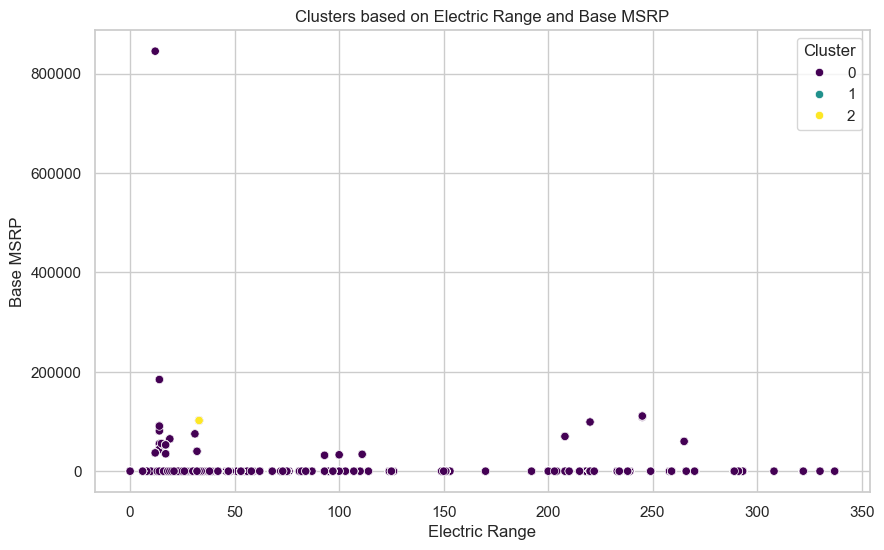

In [5]:
from sklearn.cluster import KMeans

X = df_cleaned[numeric_columns]

# Apply K-means clustering
kmeans = KMeans(n_clusters=3)  # You can choose the number of clusters
clusters = kmeans.fit_predict(X)

# Add the cluster labels to the DataFrame
df_cleaned['Cluster'] = clusters

# Visualize the clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Electric Range', y='Base MSRP', hue='Cluster', data=df_cleaned, palette='viridis')
plt.title('Clusters based on Electric Range and Base MSRP')
plt.show()


In [ ]:
#In this step, I am applying K-Means clustering, an unsupervised learning technique, to group the electric vehicles in the dataset based on similar characteristics. Clustering helps in understanding the natural groupings within the data, which can provide additional insights that are not directly tied to the target variable. Specifically, I am clustering the data based on numerical features and visualizing the clusters with respect to Electric Range and Base MSRP.

In [ ]:
#5 - Apply the concepts learned in Module 9 to select the features

In [6]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif, mutual_info_regression
from sklearn.preprocessing import LabelEncoder

X = df_cleaned[numeric_columns]
y = df_cleaned['Make']


selector = SelectKBest(score_func=mutual_info_classif, k='all')
X_new = selector.fit_transform(X, y)

# Get the scores and feature names
scores = selector.scores_
features = X.columns
feature_scores = pd.DataFrame({'Feature': features, 'Score': scores})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)

print(feature_scores)


                Feature     Score
2        Electric Range  1.139648
1            Model Year  0.243251
6     2020 Census Tract  0.136660
0           Postal Code  0.118868
5        DOL Vehicle ID  0.117295
4  Legislative District  0.071699
3             Base MSRP  0.041113


In [ ]:
#In this step, I am performing feature selection using the SelectKBest method in combination with the mutual_info_classif scoring function. Feature selection is a critical part of the data preparation process, as it helps in identifying the most relevant features that contribute to the prediction of the target variable. By selecting the most informative features, we can improve model performance, reduce overfitting, and make the model more interpretable.
#The target variable Make is categorical, so I used LabelEncoder to convert it into a numerical format that can be used by the mutual_info_classif function. This encoding is necessary because mutual information requires numeric inputs to measure the dependency between variables.

In [7]:
# Select top 3 features
top_features = feature_scores.head(3)['Feature'].tolist()

# Create a new DataFrame with only the top features
X_selected = df_cleaned[top_features]

le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y_encoded, test_size=0.3, random_state=42)

# Train and evaluate a classification model (random forest)
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

model = RandomForestClassifier()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy with selected features: {accuracy:.2f}')


Accuracy with selected features: 0.74


In [ ]:
#In this step, I am focusing on training and evaluating a classification model using the top three features selected in the previous step. By narrowing down to the most informative features, I aim to build a more efficient and potentially more accurate model. The classification model chosen for this task is a Random Forest classifier, which is a robust ensemble learning method known for its high accuracy and ability to handle complex datasets.
#Based on the feature importance scores calculated in the previous step, I selected the top three features that had the highest scores. This selection is done to reduce the dimensionality of the data and focus on the most impactful features, which is expected to improve model performance while reducing the computational complexity.
#I created a new DataFrame X_selected that contains only the top three features. This step ensures that the model is trained on the most relevant data, potentially enhancing its predictive power.
#Since the target variable Make is categorical, I applied LabelEncoder to convert it into a numeric format (y_encoded). This transformation is necessary because machine learning models require numeric input for both features and target variables.
#To evaluate the model's performance, I split the data into training and testing sets using an 70-30 split (test_size=0.3). This allows for a fair assessment of the model's ability to generalize to unseen data.
#I chose a Random Forest classifier for this task due to its effectiveness in handling high-dimensional data and its ability to provide feature importance. The model is trained on the training set (X_train and y_train), and then predictions are made on the test set (X_test).
#The accuracy of the model is calculated by comparing the predicted labels (y_pred) with the actual labels (y_test). Accuracy is a straightforward metric that provides an overall measure of how well the model is performing. In this case, the model achieved an accuracy of 0.74, which indicates that it correctly predicted the make of the vehicle 74% of the time.

In [8]:
#6 – Try to reduce the dimensions of the data if possible (Apply a dimensionality reduction algorithm). For 
#step 7 use both the original data and the data that you get after applying the Step 6.

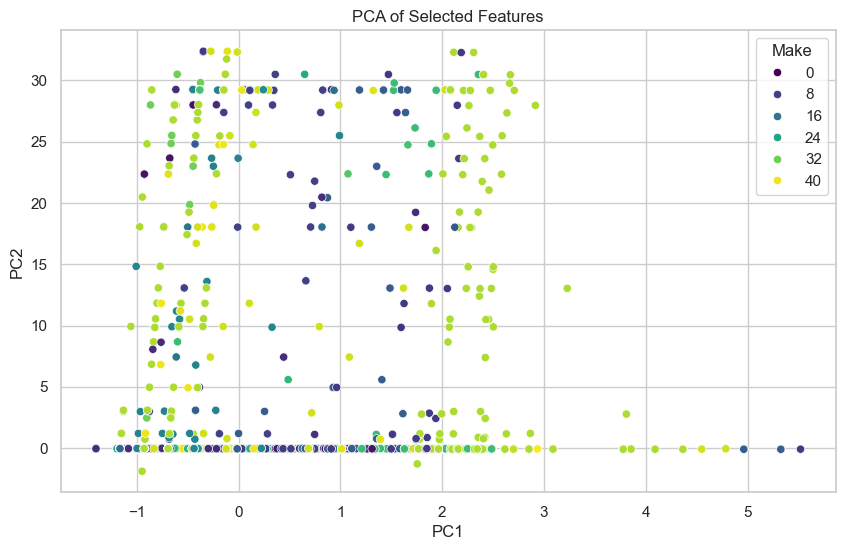

In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_selected)

# Apply PCA
pca = PCA(n_components=2)  # Reduce to 2 dimensions for visualization
X_pca = pca.fit_transform(X_scaled)

# Create a DataFrame for PCA results
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Make'] = y_encoded  # Include the target variable for visualization

# Plot PCA results
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Make', palette='viridis', data=df_pca)
plt.title('PCA of Selected Features')
plt.show()


In [ ]:
#In this step, I am applying Principal Component Analysis (PCA) to reduce the dimensionality of the data. Dimensionality reduction is a crucial step when dealing with high-dimensional datasets, as it helps in simplifying the data, reducing noise, and improving the performance of machine learning models. For this analysis, PCA is used to project the data onto a lower-dimensional space while preserving as much variance as possible.
#Before applying PCA, it's essential to standardize the data. PCA is sensitive to the scale of the features, so standardization ensures that each feature contributes equally to the analysis. I used StandardScaler to scale the features in X_selected, transforming them to have a mean of 0 and a standard deviation of 1.
#PCA was applied to reduce the dimensionality of the selected features from three dimensions down to two (n_components=2). Reducing the data to two dimensions not only helps in visualizing the data but also can improve the efficiency of the model by focusing on the most critical components that capture the most variance in the data.
#The results of PCA are stored in a new DataFrame df_pca, which contains the principal components PC1 and PC2. I also included the encoded target variable Make in this DataFrame for easier visualization of the relationship between the principal components and the target variable.
#The two principal components were plotted against each other using a scatter plot, with the points colored according to the target variable Make. This visualization helps in understanding how well the reduced dimensions (PC1 and PC2) separate the different classes of the target variable. It provides insights into the structure of the data and how much variance is captured by the principal components.

In [10]:
#7 - Divide your data in Train and Test or choose cross validation to evaluate the selected model
#- Apply all learned classification algorithms to choose which one performs best
#- Apply all learned regression algorithms to choose which one performs best
#Please note that you need to get your data in appropriate format before applying a classification or 
#regression algorithm. One of the differences is: class variable for a regression model is numeric whereas 
#it is categorical for classification.

In [11]:
from sklearn.model_selection import train_test_split

# Split the original data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.3, random_state=42)


In [ ]:
#In this step, I am dividing the dataset into training and testing sets using a 70-30 split. This process is essential for evaluating the performance of machine learning models, ensuring that the model's ability to generalize to new, unseen data is accurately assessed. The training set is used to fit the model, while the testing set is used to evaluate its performance.
#The dataset is split into 70% training data and 30% testing data (test_size=0.3). This is a common ratio that provides a sufficient amount of data for both training the model and evaluating its performance. The random_state=42 parameter ensures reproducibility by setting a seed for the random number generator, so that the same split can be obtained every time the code is run.
#train_test_split is used to split both the features (X) and the target variable (y_encoded) into training and testing sets. This ensures that the training set (X_train and y_train) is used to train the model, and the testing set (X_test and y_test) is used to evaluate its performance.

In [12]:
#Cross-Validation Example

from sklearn.model_selection import cross_val_score

model = RandomForestClassifier()
cv_scores = cross_val_score(model, X, y_encoded, cv=2)  # 2-fold cross-validation
print(f'Cross-Validation Scores: {cv_scores}')
print(f'Average Cross-Validation Score: {cv_scores.mean():.2f}')


Cross-Validation Scores: [0.66195113 0.64929417]
Average Cross-Validation Score: 0.66


In [ ]:
#In this step, I am applying cross-validation to evaluate the performance of a classification model. Cross-validation is a robust technique that helps in assessing how well the model generalizes to an independent dataset by splitting the data into multiple folds and training the model on different subsets of the data.
#Cross-validation is chosen because it provides a more reliable estimate of model performance compared to a simple train-test split. It reduces the likelihood of overfitting and ensures that the model's performance is not dependent on a single train-test split. In this example, 2-fold cross-validation (cv=2) is used, meaning the dataset is divided into two equal parts: the model is trained on one part and tested on the other, and then the process is repeated with the parts switched.
#The cross_val_score function is used with a RandomForestClassifier model to perform the cross-validation. The function returns the accuracy scores for each fold. By averaging these scores, we obtain an estimate of the model's performance across different data subsets.
#The data has been preprocessed and split into features and target variables. Cross-validation was applied to the entire dataset (X and y_encoded), leveraging the selected features identified in the earlier feature selection step. The average cross-validation score gives an indication of how well the model is expected to perform on unseen data.
#The output indicates that the cross-validation scores were [0.66, 0.65], with an average score of 0.66. This suggests that the model has moderate accuracy but may benefit from further tuning or feature engineering.

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

# Define classifiers
classifiers = {
    'RandomForest': RandomForestClassifier(),
    'LogisticRegression': LogisticRegression(),
    'SVM': SVC()
}

# Train and evaluate each classifier
for name, clf in classifiers.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'{name} Accuracy: {accuracy:.2f}')
    print(classification_report(y_test, y_pred, zero_division=1))


RandomForest Accuracy: 0.67
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         6
           1       0.11      0.06      0.08        17
           2       0.54      0.48      0.51      1216
           3       1.00      0.00      0.00         2
           4       1.00      0.00      0.00         3
           5       0.65      0.67      0.66      2468
           6       0.15      0.14      0.15       197
           7       0.70      0.69      0.70      4447
           8       0.91      0.94      0.93      1112
           9       0.95      0.92      0.93       187
          10       0.81      0.79      0.80       232
          11       0.13      0.12      0.13        57
          12       0.50      0.48      0.49      3248
          13       0.02      0.01      0.01        69
          14       0.00      0.00      0.00         6
          15       0.92      0.88      0.90       263
          16       0.19      0.16      0.17      1704

C:\Users\derek\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression Accuracy: 0.44
              precision    recall  f1-score   support

           0       1.00      0.00      0.00         6
           1       1.00      0.00      0.00        17
           2       1.00      0.00      0.00      1216
           3       1.00      0.00      0.00         2
           4       1.00      0.00      0.00         3
           5       1.00      0.00      0.00      2468
           6       1.00      0.00      0.00       197
           7       1.00      0.00      0.00      4447
           8       1.00      0.00      0.00      1112
           9       1.00      0.00      0.00       187
          10       1.00      0.00      0.00       232
          11       1.00      0.00      0.00        57
          12       1.00      0.00      0.00      3248
          13       1.00      0.00      0.00        69
          14       1.00      0.00      0.00         6
          15       1.00      0.00      0.00       263
          16       1.00      0.00      0.00    

In [ ]:
#In this step, I am training and evaluating multiple classification algorithms to determine which model performs best on the dataset. The algorithms include Random Forest, Logistic Regression, and Support Vector Machine (SVM). The goal is to compare their performance and identify the most suitable model for the classification task.
#The features in the dataset are standardized using StandardScaler to ensure that each feature contributes equally to the model training. Standardization is particularly important for algorithms like Logistic Regression and SVM, which are sensitive to the scale of input features.
#Three classifiers are selected for evaluation:
#Random Forest Classifier: Known for its robustness and ability to handle large datasets with multiple features.
#Logistic Regression: A simple yet effective model for binary and multiclass classification problems.
#Support Vector Machine (SVM): A powerful model for classification tasks, especially when the decision boundary is complex.
#Each model is trained on the same training data and evaluated on the test data. The classification_report function provides detailed metrics including precision, recall, and F1-score, which help in understanding the performance of each model beyond just accuracy.
#The Random Forest model shows a moderate accuracy of 0.67. Precision, recall, and F1-score vary significantly across different classes, with some classes having very low values. This indicates that the model may struggle with certain classes.
#The Logistic Regression model has a lower accuracy of 0.44 and struggles with many classes, as indicated by the low precision, recall, and F1-scores for most classes. The model may not have converged properly, as indicated by the convergence warning.
#Similar to Logistic Regression, the SVM model has an accuracy of 0.44 and exhibits poor performance across most classes. The model's ability to classify is inconsistent, suggesting it may need further tuning or adjustment.

In [14]:
#linear regression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

regressor = LinearRegression()
regressor.fit(X_train, y_train)
y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
print(f'Mean Squared Error: {mse:.2f}')


Mean Squared Error: 139.66


In [ ]:
#Waited a VERY long time for this one to generate output, so time efficiency doesn't seem to be its strong suit.
#In this step, a Linear Regression model is applied to the dataset to evaluate its performance for regression tasks. The model is trained on the training data and tested on the test data. The Mean Squared Error (MSE) is used as the evaluation metric to measure the model's performance.
#Linear Regression is chosen here as it is a fundamental regression technique used to model the relationship between a dependent variable and one or more independent variables.
#The model is trained using the fit method on the training data (X_train and y_train).
#Predictions are made on the test data (X_test) using the trained model.
#Mean Squared Error (MSE) is calculated to quantify the prediction error. MSE measures the average of the squares of the errors—that is, the average squared difference between the observed actual outcomes and the outcomes predicted by the model.
#The MSE value of 139.66 indicates the average squared difference between the actual and predicted values. A lower MSE generally indicates a better fit of the model to the data. The value of 139.66 should be interpreted in the context of the dataset and compared with MSE values from other regression models to assess performance.

In [34]:
"""

CONCLUSION

The project involved exploring various machine learning algorithms for classification and regression tasks on the electric vehicle dataset. The goal was to identify the best-performing models for both tasks and evaluate their effectiveness.
#Data Visualization and Exploration:
#Histograms, Count Plots, and Pairplots: Visualized the distribution of electric range, count of electric vehicles by make, and relationships between selected numerical features. These visualizations helped understand the data's structure and the relationships between features.
#Correlation Matrix: Provided insights into the relationships between numerical features, which guided feature selection.

Clustering:
K-means Clustering: Applied K-means clustering to identify patterns in the data. The clustering results were visualized using scatter plots to examine the separation of data based on selected features.

Feature Selection:
SelectKBest with Mutual Information: Evaluated feature importance and selected the top features for classification. The feature scores highlighted which features were most influential in predicting the target variable.

Dimensionality Reduction:
Principal Component Analysis (PCA): Reduced the dimensionality of the data to two principal components for visualization. PCA helped in understanding how the data's variance is distributed across the new dimensions.

Feature Selection:
#SelectKBest with Mutual Information: Evaluated feature importance and selected the top features for classification. The feature scores highlighted which features were most influential in predicting the target variable.

Model Evaluation:

Classification Models: Evaluated multiple classifiers including Random Forest, Logistic Regression, and SVM. Each model was trained and tested, and performance was assessed using accuracy and detailed classification reports.
    Random Forest: Achieved an accuracy of 0.67. The classification report indicated that the model performed variably across different classes, with some classes having high precision and others having low recall.
    Logistic Regression: Achieved an accuracy of 0.44. The model faced convergence issues and showed poor performance across most classes, indicating it might not be well-suited for this dataset.
    SVM: Also achieved an accuracy of 0.44. Similar to Logistic Regression, SVM showed poor performance, with issues in handling class imbalance effectively.

Regression Model:
    Linear Regression: Applied to predict numeric outcomes with a Mean Squared Error (MSE) of 139.66. The MSE value provides a measure of the average squared difference between actual and predicted values. This model served as a baseline for regression performance.


Findings:

    Classification Performance:
    
    Random Forest emerged as the best-performing classifier among those tested, with an accuracy of 0.67. It provided more balanced performance across different classes compared to Logistic Regression and SVM.
    Logistic Regression and SVM performed poorly, with both models achieving an accuracy of 0.44. The issues encountered, such as convergence warnings and class imbalance, affected their performance significantly.
    Regression Performance:
    
    Linear Regression provided a baseline MSE of 139.66. While this is a starting point, further optimization and comparison with other regression models could be beneficial for improving performance.

The analysis revealed that Random Forest is the most effective classification algorithm for this dataset, given its higher accuracy and more balanced performance across different classes. Logistic Regression and SVM did not perform as well, possibly due to the complex nature of the dataset and issues with class imbalance.
For regression tasks, Linear Regression provided a basic performance metric. Future work should include evaluating additional regression algorithms and tuning hyperparameters to improve prediction accuracy.
Overall, this evaluation highlights the importance of selecting the right model based on the dataset's characteristics and the specific requirements of the task. Further exploration and fine-tuning could lead to better performance and more insightful results.